In [ ]:
# Import Libraries for model training
import os
import pickle
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier

os.makedirs('../data', exist_ok=True)
os.makedirs('../models', exist_ok=True)
print("Environment Setup Completed")

Environment Setup Completed


In [35]:
# Building the preprocess data function 
class EmailPreprocessor:
    def __init__(self):
        # Email domain that often be used to send spam email
        self.free_email_domains = ['gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com', 'live.com']
        
    def process(self, raw_text):
        if not isinstance(raw_text, str): 
            # Check if the current data is string or not
            return {} 

        # 1. Extract Header & Body
        sender_match = re.search(r"From:\s*(.+)", raw_text)
        subject_match = re.search(r"Subject:\s*(.+)", raw_text)
        
        # Group(1) ensure the model to take the part after "from:" and "Subject:"
        sender = sender_match.group(1).strip() if sender_match else "" #Return empty string if not found data
        subject = subject_match.group(1).strip() if subject_match else ""
        
        # Take the body (content) 
        body = re.sub(r"From:.*?\n", "", raw_text, count=1)
        body = re.sub(r"Subject:.*?\n", "", body, count=1).strip() 
        
        # Take out the URL (Often the link start with http/https)
        #Pattern of the URL
        url_pattern = r"(https?://\S+|www\.\S+|\b\w+\.(?:com|net|org|info|biz|xyz|tk)\b)"
        #Find the URl pattern in the body, convert to lower
        urls = re.findall(url_pattern, raw_text.lower())
        
        # Collect the text
        full_text = f"{subject} {body}"
        clean_text = re.sub(url_pattern, " url ", full_text).lower() # Exchange URLs with a shared token
        # Clean the text one more time
        clean_text = re.sub(r'\s+', ' ', clean_text).strip()

            
        # Collect the length of the email (The text)
        email_length = len(full_text) if len(full_text) > 0 else 1 # Tránh chia cho 0
        
        # Check the ratio of capitalization and Exclamation mark
        num_exclamation = full_text.count('!')
        upper_case_count = sum(1 for c in full_text if c.isupper())
        upper_case_ratio = upper_case_count / email_length
        
        # Ratio of URL over text, check if there are too many URLs in the email
        num_urls = len(urls)
        url_to_text_ratio = num_urls / email_length
        
        # Search for igcognito / generic greeting 
        has_generic_greeting = 1 if re.search(r"(dear|hi|hello)\s+(customer|user|winner|friend|student)", full_text.lower()) else 0
        
        # Check for the sender domain (@...)
        domain = sender.split('@')[-1].lower() if '@' in sender else ""
        is_free_email = 1 if domain in self.free_email_domains else 0
        
        return {
            "Sender": sender,
            "Title": subject,
            "num_urls": num_urls,
            "email_length": email_length,
            "num_exclamation": num_exclamation,
            "upper_case_ratio": round(upper_case_ratio, 4),
            "url_to_text_ratio": round(url_to_text_ratio, 6),
            "has_generic_greeting": has_generic_greeting,
            "is_free_email": is_free_email,
            "full_clean_text": clean_text
        }

print("Finished the email processing process")

Finished the email processing process


In [36]:
# Preprocess data function calling and file saving
print("Processing the raw data")
# Insert the data
df_raw = pd.read_csv('../data/email_classification_dataset.csv')

# Call the email processor function
preprocessor = EmailPreprocessor()

# Preprocess the whole raw email
processed_list = df_raw['email'].apply(preprocessor.process).tolist()
df_features = pd.DataFrame(processed_list)

# Label the email
df_final = pd.concat([df_raw[['id', 'label']], df_features], axis=1)

# Save the file for future process
df_final.to_csv('../data/processed_email_data.csv', index=False)
print(f"Preprocess data successfully'")

# Print the first 3 line of the processed email
df_final.head(3)

Processing the raw data
Preprocess data successfully'


,id,label,Sender,Title,num_urls,email_length,num_exclamation,upper_case_ratio,url_to_text_ratio,has_generic_greeting,is_free_email,full_clean_text
0,2685,ham,support@legitcompany.com,Regarding Your Recent Inquiry,1,212,0,0.0472,0.004717,0,0,regarding your recent inquiry thank you for re...
1,5857,ham,noreply@softwareupdates.com,Weekly Newsletter - Latest Updates,1,246,0,0.0650,0.004065,0,0,weekly newsletter - latest updates please find...
2,2399,ham,noreply@softwareupdates.com,Important: Software Update Notification,1,225,0,0.0489,0.004444,0,0,important: software update notification thank ...


In [ ]:
# Leakage-free split, feature fitting, model training, and evaluation

numeric_features = [
    'num_urls', 'email_length', 'num_exclamation',
    'upper_case_ratio', 'url_to_text_ratio',
    'has_generic_greeting', 'is_free_email'
]

X_raw = df_final[['full_clean_text'] + numeric_features].copy()
y_raw = df_final['label'].copy()

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    stratify=y_raw,
    test_size=0.3,
    random_state=42,
)

# Fit text and numeric preprocessors on train only
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
vectorizer.fit(X_train_raw['full_clean_text'])

scaler = StandardScaler()
scaler.fit(X_train_raw[numeric_features])

# Transform train and test separately
X_train_text = vectorizer.transform(X_train_raw['full_clean_text'])
X_test_text = vectorizer.transform(X_test_raw['full_clean_text'])

X_train_num = scaler.transform(X_train_raw[numeric_features])
X_test_num = scaler.transform(X_test_raw[numeric_features])

X_train = hstack([X_train_text, csr_matrix(X_train_num)]).toarray()
X_test = hstack([X_test_text, csr_matrix(X_test_num)]).toarray()

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

# Retrain models on train split only
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
)
xgb_model.fit(X_train, y_train)

lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
)
lgb_model.fit(X_train, y_train)

# Evaluate the same ensemble logic used at inference time
final_prob = (xgb_model.predict_proba(X_test) + lgb_model.predict_proba(X_test)) / 2
y_pred = np.argmax(final_prob, axis=1)

# Simulate the old notebook bug where 0 was displayed as SPAM and 1 as HAM
legacy_reversed_y_pred = 1 - y_pred

legacy_cm = confusion_matrix(y_test, legacy_reversed_y_pred)
fixed_cm = confusion_matrix(y_test, y_pred)

print('Before label fix confusion matrix (legacy reversed mapping):')
print(pd.DataFrame(legacy_cm, index=label_encoder.classes_, columns=label_encoder.classes_))
print()
print('After label fix confusion matrix (label_encoder mapping):')
print(pd.DataFrame(fixed_cm, index=label_encoder.classes_, columns=label_encoder.classes_))
print()
print('Classification report (after fix):')
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

with open('../models/vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

with open('../models/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('../models/lgb_model.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')
print('Saved updated vectorizer, scaler, label encoder, XGBoost, and LightGBM artifacts')


C:\Users\12a5n\AppData\Local\Temp\ipykernel_19480\1984187627.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette=colors)


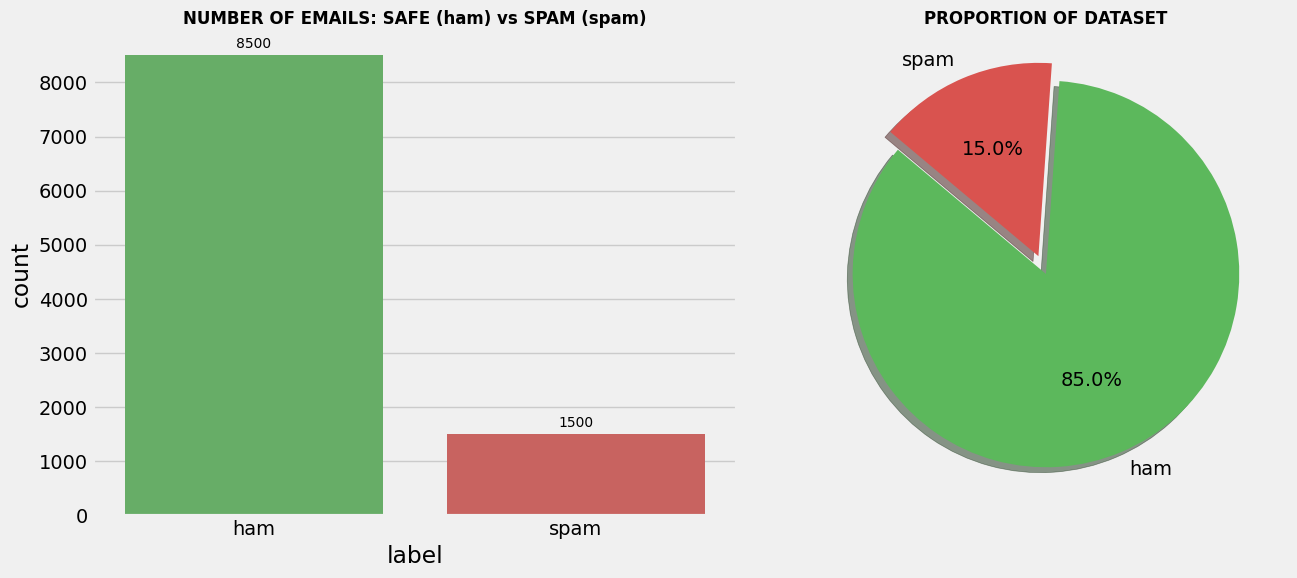

In [38]:
# =========================================================
# DATASET DISTRIBUTION VISUALIZATION
# =========================================================

def plot_distribution(df):
    plt.figure(figsize=(14, 6))
    plt.style.use('fivethirtyeight') 
    
    # Colors: Green for Ham (Safe), Red for Spam (Harm)
    colors = ['#5cb85c', '#d9534f'] 
    
    # 1. Bar Chart: Absolute Counts
    plt.subplot(1, 2, 1)
    ax = sns.countplot(x='label', data=df, palette=colors)
    plt.title('NUMBER OF EMAILS: SAFE (ham) vs SPAM (spam)', fontsize=12, fontweight='bold')
    
    # Annotate counts on top of bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='baseline', fontsize=10, xytext=(0, 5),
                    textcoords='offset points')

    # 2. Pie Chart: Proportion
    plt.subplot(1, 2, 2)
    label_counts = df['label'].value_counts()
    plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', 
            startangle=140, colors=colors, explode=[0, 0.1], shadow=True)
    plt.title('PROPORTION OF DATASET', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Execute plot
plot_distribution(df_final)

C:\Users\12a5n\AppData\Local\Temp\ipykernel_19480\848591436.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Score', y='Feature', data=mi_df, palette='magma')


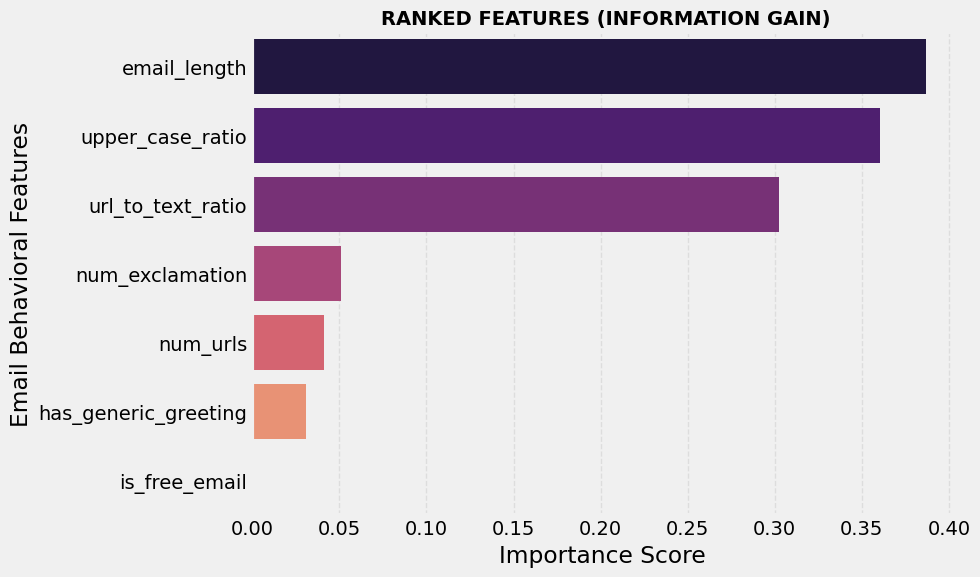

In [ ]:
# RANKED FEATURES (Mutual Information) for Email 


# Prepare the data
# Use only numeric features for Mutual Information calculation
numeric_features = [
    'num_urls', 'email_length', 'num_exclamation', 
    'upper_case_ratio', 'url_to_text_ratio', 
    'has_generic_greeting', 'is_free_email'
]
X_eda = df_final[numeric_features]
y_eda = df_final['label']

# Calculate Mutual Information (Information Gain)
# This measures the dependency between each feature and the 'spam/ham' target
importances = mutual_info_classif(X_eda, y_eda, random_state=42)

# 3. Create a result table
mi_df = pd.DataFrame({
    'Feature': X_eda.columns,
    'Importance_Score': importances
}).sort_values(by='Importance_Score', ascending=False)

# Plot Feature Importance 
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance_Score', y='Feature', data=mi_df, palette='magma')

plt.title('RANKED FEATURES (INFORMATION GAIN)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score ')
plt.ylabel('Email Behavioral Features')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

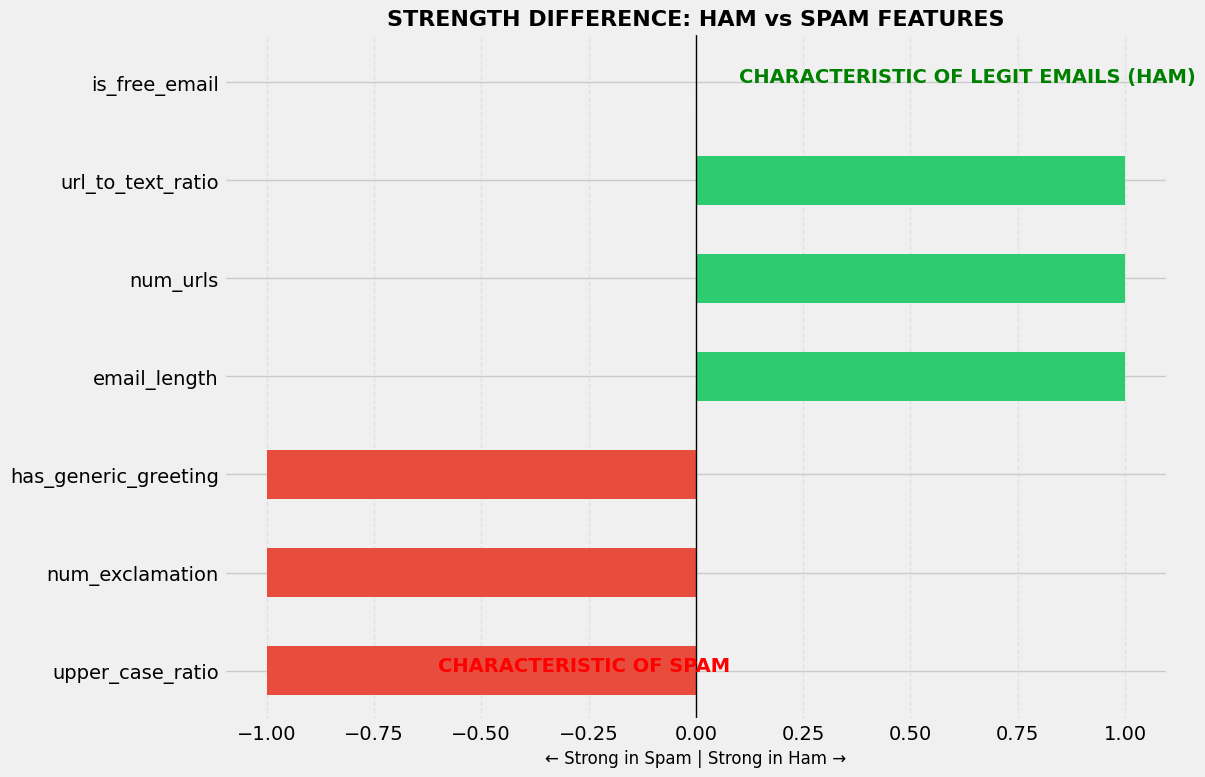

In [40]:
#  4. STRENGTH DIFFERENCE (HAM vs SPAM)
# Calculate the difference between HAM & SPAM emails

# Group by label and calculate mean of numeric features
summary = df_final[numeric_features + ['label']].groupby('label').mean()

# Normalization to compare features (scale 0 to 1)
summary_norm = (summary - summary.min()) / (summary.max() - summary.min())

# HAM SCORE: Positive means characteristic of HAM, NEGATIVE means characteristic of SPAM
# Strength = (mean value of Ham) - (mean value of Spam)
ham_strength = (summary_norm.loc['ham'] - summary_norm.loc['spam']).sort_values()

# Create horizontal bar chart
plt.figure(figsize=(12, 8))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in ham_strength]
ham_strength.plot(kind='barh', color=colors)

# Arrange to clearly show Strong/Weak
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.title('STRENGTH DIFFERENCE: HAM vs SPAM FEATURES', fontsize=16, fontweight='bold')
plt.xlabel('← Strong in Spam | Strong in Ham →', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Add text annotations for clarity
plt.text(0.1, len(ham_strength)-1, 'CHARACTERISTIC OF LEGIT EMAILS (HAM)', color='green', fontweight='bold')
plt.text(-0.6, 0, 'CHARACTERISTIC OF SPAM', color='red', fontweight='bold')

plt.tight_layout()
plt.show()